# Implementação da LeNet-5 com PyTorch

Este notebook demonstra a implementação da arquitetura clássica **LeNet-5**, desenvolvida por Yann LeCun em 1998. Ela foi uma das primeiras redes neurais convolucionais (CNNs) de sucesso, projetada originalmente para o reconhecimento de caracteres em cheques bancários.

### O que estamos treinando?
Estamos treinando o modelo no dataset **MNIST**, que contém 60.000 imagens de treinamento e 10.000 de teste de dígitos manuscritos (0 a 9). Cada imagem é em escala de cinza e tem 28x28 pixels.

### Por que a LeNet-5?
Embora seja antiga, ela contém os fundamentos das CNNs modernas:
1. **Camadas Convolucionais**: Para extrair características espaciais (bordas, curvas).
2. **Camadas de Pooling**: Para reduzir a dimensionalidade e tornar o modelo invariante a pequenas translações.
3. **Camadas Totalmente Conectadas (Dense)**: Para a classificação final baseada nas características extraídas.

In [1]:
import torch # Biblioteca principal do PyTorch para tensores
import torch.nn as nn # Módulo para camadas de redes neurais
import torch.optim as optim # Otimizadores como Adam ou SGD
import torchvision # Ferramentas para visão computacional
import torchvision.transforms as transforms # Transformações de imagem (ex: converter para tensor)
from torch.utils.data import DataLoader # Para carregar os dados em "lotes" (batches)
import matplotlib.pyplot as plt # Para plotar gráficos
import numpy as np # Operações matemáticas básicas

## 1. Definição da Arquitetura LeNet-5

A LeNet-5 original usa:
- 2 Camadas Convolucionais
- 2 Camadas de Subsampling (Pooling)
- 3 Camadas Totalmente Conectadas

Adicionamos `BatchNorm` para estabilizar o treinamento e `ReLU` como função de ativação (na original era Tanh ou Sigmoid).

In [2]:
class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        
        # Primeira Camada: Convolução -> BatchNorm -> ReLU -> Pooling
        self.layer1 = nn.Sequential(
            # Conv2d(canais_entrada, canais_saída, tamanho_filtro)
            # Usamos padding=2 para que a imagem 28x28 se comporte como 32x32 (padrão da LeNet original)
            nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2), 
            nn.BatchNorm2d(6), # Normaliza os dados para acelerar o treino
            nn.ReLU(), # Função de ativação: introduz não-linearidade
            nn.AvgPool2d(kernel_size=2, stride=2)) # Reduz o tamanho da imagem pela metade
        
        # Segunda Camada: Convolução -> BatchNorm -> ReLU -> Pooling
        self.layer2 = nn.Sequential(
            nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2))
        
        # Camadas Final (Totalmente Conectadas - Classifier)
        self.fc = nn.Sequential(
            nn.Linear(16*5*5, 120), # 16 canais de 5x5 pixels de saída da camada anterior
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, num_classes)) # Saída final = 10 classes (dígitos 0-9)
        
    # Método que define o fluxo dos dados pela rede
    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        # "Achatamos" a matriz para um vetor antes de passar para a camada Linear
        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        return out

## 2. Configurações e Carregamento de Dados

Aqui preparamos as imagens. A normalização com média 0.1307 e desvio padrão 0.3081 é padrão para o MNIST para ajudar a rede a convergir mais rápido.

In [ ]:
import os
from PIL import Image
from torch.utils.data import Dataset

class MRIDataset(Dataset):
    
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = os.listdir(image_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):

        img_path = os.path.join(self.image_dir, self.images[index])
        mask_path = os.path.join(self.mask_dir, self.images[index])

        image = Image.open(img_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        return image, mask

# Transformações de imagem

In [ ]:
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

In [ ]:
dataset = MRIDataset(
    image_dir="./dataset/images",
    mask_dir="./dataset/masks",
    transform=transform
)

train_loader = DataLoader(dataset, batch_size=8, shuffle=True)

## 3. Loop de Treinamento

No treinamento, para cada lote:
1. Passamos os dados pela rede (**Forward**).
2. Calculamos o erro (**Loss**).
3. Calculamos o gradiente (**Backward**).
4. O otimizador ajusta os pesos (**Step**).

In [ ]:
# Detecta se temos uma GPU disponível
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LeNet5().to(device)

# Função de perda: CrossEntropy é ideal para classificação multicalss
criterion = nn.BCEWithLogitsLoss()

# Otimizador Adam: Ajusta os pesos de forma eficiente
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

total_step = len(train_loader)
train_losses = []

for epoch in range(num_epochs):
    model.train() # Coloca o modelo em modo de treinamento
    for i, (images, masks) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        # 1. Forward pass
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        # 2. Backward pass e otimização
        optimizer.zero_grad() # Limpa os gradientes anteriores
        loss.backward() # Calcula os novos gradientes
        optimizer.step() # Atualiza os pesos
        masks = masks.float().to(device)
        if (i+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Passo [{i+1}/{total_step}], Perda (Loss): {loss.item():.4f}')
            train_losses.append(loss.item())

print("Treinamento Concluído!")

Epoch [1/5], Passo [100/938], Perda (Loss): 0.1355
Epoch [1/5], Passo [200/938], Perda (Loss): 0.1265
Epoch [1/5], Passo [300/938], Perda (Loss): 0.0820
Epoch [1/5], Passo [400/938], Perda (Loss): 0.1591
Epoch [1/5], Passo [500/938], Perda (Loss): 0.0380
Epoch [1/5], Passo [600/938], Perda (Loss): 0.1416
Epoch [1/5], Passo [700/938], Perda (Loss): 0.1832
Epoch [1/5], Passo [800/938], Perda (Loss): 0.0267
Epoch [1/5], Passo [900/938], Perda (Loss): 0.1396
Epoch [2/5], Passo [100/938], Perda (Loss): 0.0159
Epoch [2/5], Passo [200/938], Perda (Loss): 0.0635
Epoch [2/5], Passo [300/938], Perda (Loss): 0.0186
Epoch [2/5], Passo [400/938], Perda (Loss): 0.1190
Epoch [2/5], Passo [500/938], Perda (Loss): 0.0310
Epoch [2/5], Passo [600/938], Perda (Loss): 0.0353
Epoch [2/5], Passo [700/938], Perda (Loss): 0.0128
Epoch [2/5], Passo [800/938], Perda (Loss): 0.0126
Epoch [2/5], Passo [900/938], Perda (Loss): 0.0230
Epoch [3/5], Passo [100/938], Perda (Loss): 0.0445
Epoch [3/5], Passo [200/938], P

## 4. Validação e Teste

Agora testamos o modelo em imagens que ele **nunca viu** durante o treinamento para medir a acurácia real.

In [12]:
model.eval() # Modo de avaliação (desativa BatchNorm/Dropout se houver)
with torch.no_grad(): # Desativa o cálculo de gradientes (economiza memória/tempo)
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        # Retorna o índice com o maior valor (a classe prevista)
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f'Acurácia do modelo no dataset de teste: {100 * correct / total:.2f}%')

Acurácia do modelo no dataset de teste: 98.79%


## 5. Visualização do Progresso

O gráfico abaixo mostra como a "Loss" (o erro) diminuiu ao longo do tempo. Quanto menor a loss, mais o modelo está aprendendo a reconhecer os padrões.

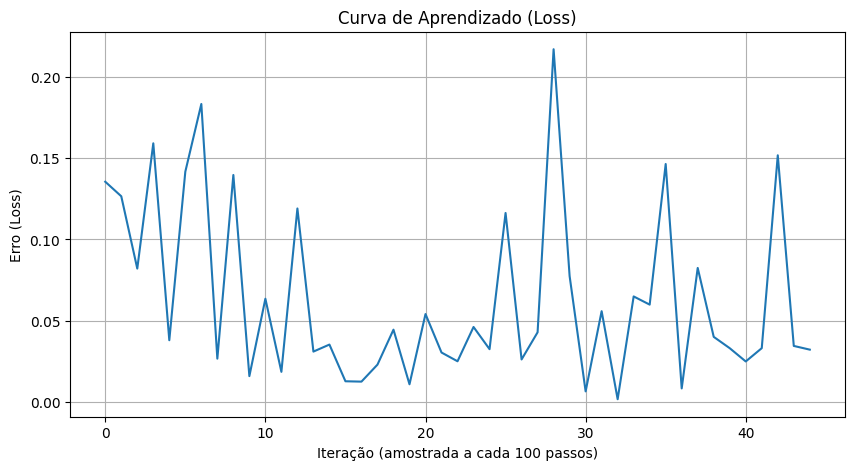

In [13]:
plt.figure(figsize=(10,5))
plt.plot(train_losses)
plt.title('Curva de Aprendizado (Loss)')
plt.xlabel('Iteração (amostrada a cada 100 passos)')
plt.ylabel('Erro (Loss)')
plt.grid(True)
plt.show()